### 2 player, 2 action

In [1]:
import numpy as np
np.random.seed(23423)
R0 = np.round(np.random.uniform(0,1,(2,2)),2)
R1 = np.round(np.random.uniform(0,1,(2,2)),2)

def check_nash(R0, R1):
    N = R0.shape[0]
    nash_eqbms = []
    for a0 in range(N):
        for a1 in range(N):
            br0 = np.argmax(R0[:, a1])
            br1 = np.argmax(R1[a0, :])
            if (br0 == a0) and (br1 == a1):
                nash_eqbms.append([a0, a1])
    return nash_eqbms

print(R0)
print(R1)
check_nash(R0, R1)

[[0.89 0.05]
 [0.59 0.74]]
[[0.55 0.01]
 [0.47 0.57]]


[[0, 0], [1, 1]]

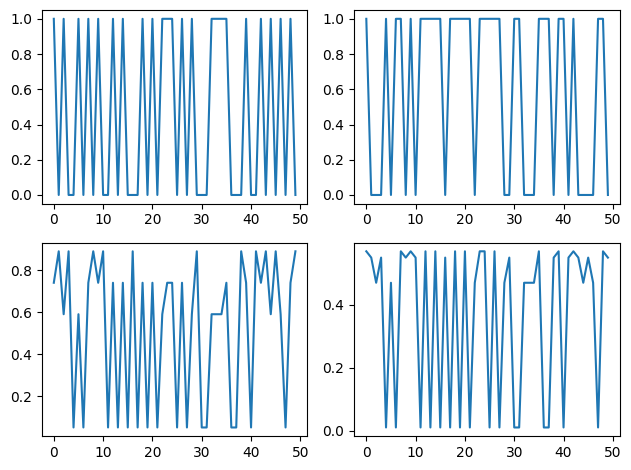

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def normal_form_game(a0, a1, R0, R1): 
    return R0[a0, a1], R1[a0, a1]

T = 50

def random_action():
    return np.random.choice([0,1])

history = []
for t in range(T):
    a0 = random_action()
    a1 = random_action()
    r0, r1 = normal_form_game(a0, a1, R0, R1)
    history.append([a0, a1, r0, r1])

def plot_history(history):
    fig, axs = plt.subplots(2, 2)
    axs[0, 0].plot(range(T), [history[i][0] for i in range(T)]); 
    axs[0, 1].plot(range(T), [history[i][1] for i in range(T)])
    axs[1, 0].plot(range(T), [history[i][2] for i in range(T)])
    axs[1, 1].plot(range(T), [history[i][3] for i in range(T)])
    plt.tight_layout(); plt.show()

plot_history(history)

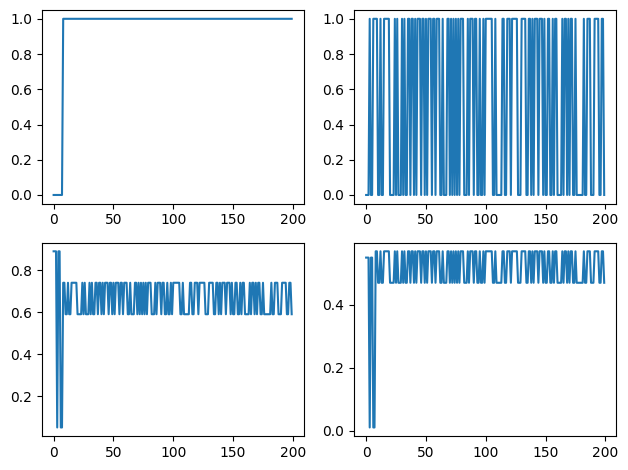

In [3]:
def brown_ficticious_play(player_idx, round_idx, history, R0, R1):

    if round_idx==0:
        return random_action()
        
    if player_idx == 0:
        opp_idx = 1
        rewards = R0
    else:
        opp_idx = 0
        rewards = R1

    N = len(history)
    opp_actions = [history[i][opp_idx] for i in range(N)]
    opp_probs = np.bincount(opp_actions, minlength=2)/N

    if player_idx == 0:
        exp_payoffs = [np.dot(rewards[0,:].T, opp_probs), np.dot(rewards[1,:].T, opp_probs)]
        best_response_idx = np.argmax(exp_payoffs)
    else:
        exp_payoffs = [np.dot(rewards[:,0].T, opp_probs), np.dot(rewards[:,1].T, opp_probs)]
        best_response_idx = np.argmax(exp_payoffs)
        
    return best_response_idx

T = 200
history = []
for t in range(T):
    a0 = brown_ficticious_play(0, t, history, R0, R1)
    a1 = random_action()
    r0, r1 = normal_form_game(a0, a1, R0, R1)
    history.append([a0, a1, r0, r1])

plot_history(history)

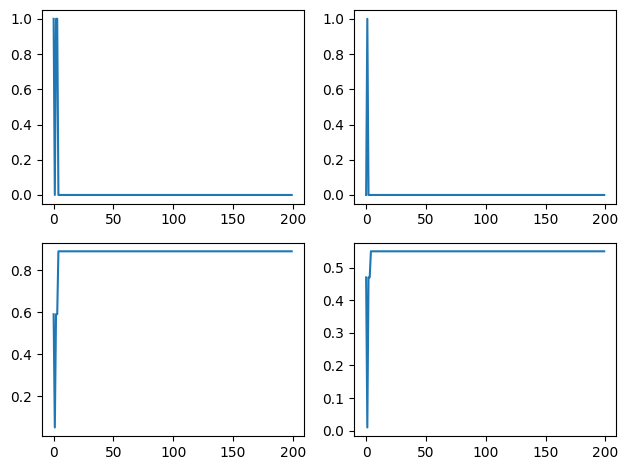

0 0


In [4]:
T = 200
history = []
for t in range(T):
    a0 = brown_ficticious_play(0, t, history, R0, R1)
    a1 = brown_ficticious_play(1, t, history, R0, R1)
    r0, r1 = normal_form_game(a0, a1, R0, R1)
    history.append([a0, a1, r0, r1])
plot_history(history)
print(a0, a1)

### 2 player, 3 actions

In [5]:
np.random.seed(13233)
R0 = np.round(np.random.uniform(0,1,(3,3)),2)
R1 = np.round(np.random.uniform(0,1,(3,3)),2)

def check_nash(R0, R1):
    N = R0.shape[0]
    nash_eqbms = []
    for a0 in range(N):
        for a1 in range(N):
            br0 = np.argmax(R0[:, a1])
            br1 = np.argmax(R1[a0, :])
            if (br0 == a0) and (br1 == a1):
                nash_eqbms.append([a0, a1])
    return nash_eqbms

print(R0)
print(R1)
check_nash(R0, R1)

[[0.56 0.88 0.63]
 [0.97 0.31 0.24]
 [0.42 0.97 0.69]]
[[0.41 0.7  0.8 ]
 [0.57 0.41 0.11]
 [0.59 0.2  0.98]]


[[1, 0], [2, 2]]

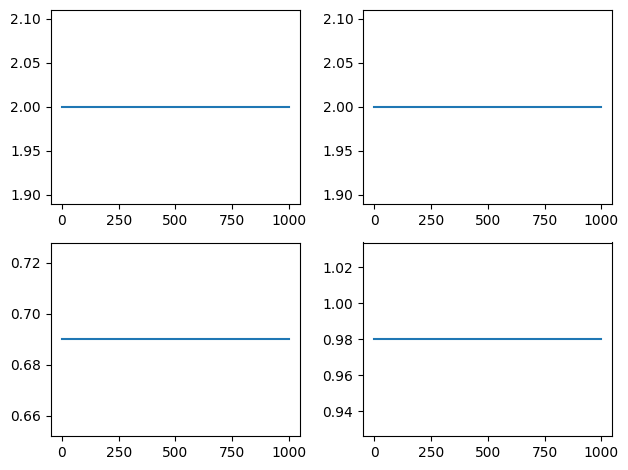

2 2


In [6]:
def brown_ficticious_play(player_idx, round_idx, history, R0, R1):

    M = R0.shape[0]
    N = len(history)
    
    if round_idx==0:
        return np.random.choice(list(range(M)))
        
    if player_idx == 0:
        opp_idx = 1
        rewards = R0
    else:
        opp_idx = 0
        rewards = R1


    opp_actions = [history[i][opp_idx] for i in range(N)]
    opp_probs = np.bincount(opp_actions, minlength=M)/N
    
    if player_idx == 0:
        exp_payoffs = [np.dot(rewards[i,:].T, opp_probs) for i in range(M)]
        best_response_idx = np.argmax(exp_payoffs)
    else:
        exp_payoffs = [np.dot(rewards[:,i].T, opp_probs) for i in range(M)]
        best_response_idx = np.argmax(exp_payoffs)
        
    return best_response_idx

T = 1000
history = []
for t in range(T):
    a0 = brown_ficticious_play(0, t, history, R0, R1)
    a1 = brown_ficticious_play(1, t, history, R0, R1)
    r0, r1 = normal_form_game(a0, a1, R0, R1)
    history.append([a0, a1, r0, r1])

plot_history(history)
print(a0, a1)

### no convergence in rock-paper-scissors

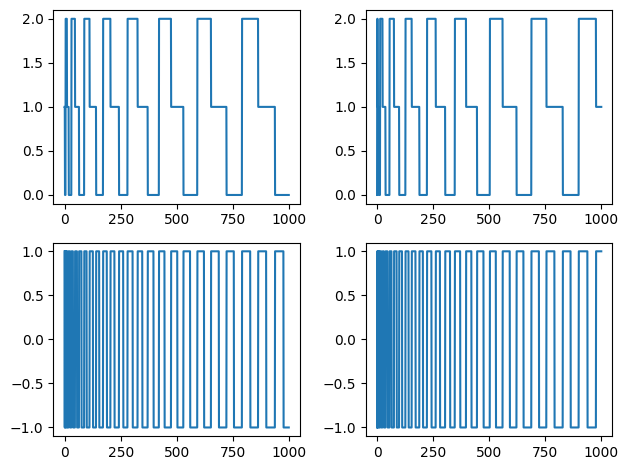

0 1


In [7]:
np.random.seed(13233)

# r, p, s
R0 = np.array([[0, -1, 1],
               [1, 0, -1], 
               [-1, 1, 0]])
R1 = np.array([[0, 1, -1],
               [-1, 0, 1], 
               [1, -1, 0]])

check_nash(R0, R1)

T = 1000
history = []
for t in range(T):
    a0 = brown_ficticious_play(0, t, history, R0, R1)
    a1 = brown_ficticious_play(1, t, history, R0, R1)
    r0, r1 = normal_form_game(a0, a1, R0, R1)
    history.append([a0, a1, r0, r1])

plot_history(history)
print(a0, a1)

### stochastic ficticious play

In [8]:
def stochastic_ficticious_play(player_idx, round_idx, history, R0, R1, tau = 1):
    M = R0.shape[0]
    N = len(history)
    
    if round_idx==0:
        return np.random.choice(list(range(M))), np.ones(M)/M
        
    if player_idx == 0:
        opp_idx = 1
        rewards = R0
    else:
        opp_idx = 0
        rewards = R1
    
    opp_actions = [history[i][opp_idx] for i in range(N)]
    opp_probs = np.bincount(opp_actions, minlength=M)/N

    if player_idx == 0:
        exp_payoffs = np.array([np.dot(rewards[i,:], opp_probs) for i in range(M)])
    else:
        exp_payoffs = np.array([np.dot(rewards[:,i], opp_probs) for i in range(M)])

    base = np.sum(np.exp(tau*exp_payoffs))
    top = np.exp(tau*exp_payoffs)
    best_response_idx = np.random.choice(list(range(M)), p = np.divide(top, base))
    
    return best_response_idx, np.divide(top, base)



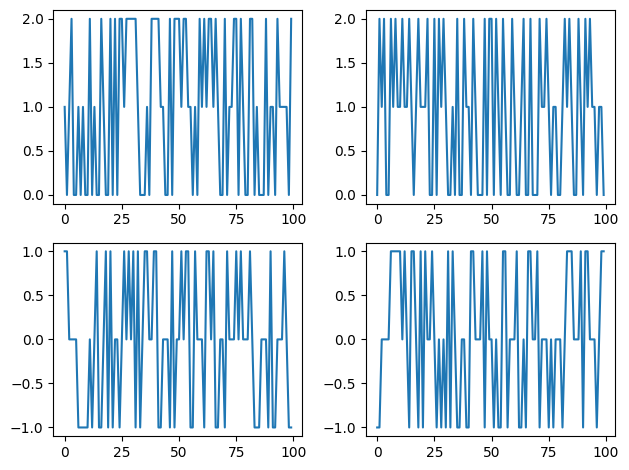

[0.31334754 0.35372687 0.33292559]
[0.35372687 0.33292559 0.31334754]


In [9]:
np.random.seed(13233)

# r, p, s
R0 = np.array([[0, -1, 1],
               [1, 0, -1], 
               [-1, 1, 0]])
R1 = np.array([[0, 1, -1],
               [-1, 0, 1], 
               [1, -1, 0]])

check_nash(R0, R1)

T = 100
history = []
for t in range(T):
    a0, p0 = stochastic_ficticious_play(0, t, history, R0, R1, 1)
    a1, p1 = stochastic_ficticious_play(1, t, history, R0, R1, 1)
    r0, r1 = normal_form_game(a0, a1, R0, R1)
    history.append([a0, a1, r0, r1, p0, p1])

plot_history(history)
print(p0)
print(p1)

### Matching pennies

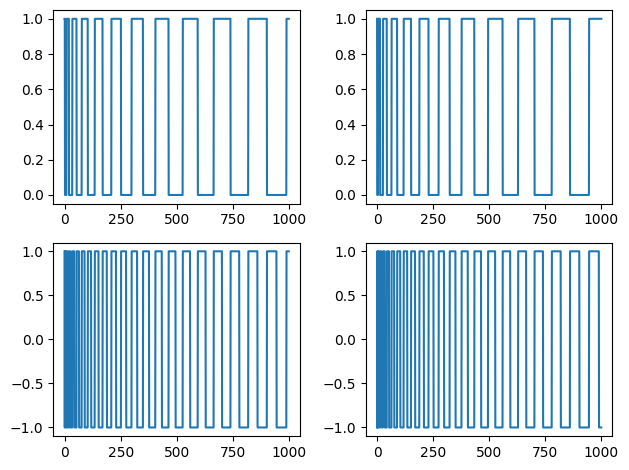

1 1


In [10]:
np.random.seed(13233)

# r, p, s
R0 = np.array([[1, -1],
               [-1, 1]]) 
R1 = np.array([[-1, 1],
               [1, -1]])

check_nash(R0, R1)

T = 1000
history = []
for t in range(T):
    a0 = brown_ficticious_play(0, t, history, R0, R1)
    a1 = brown_ficticious_play(1, t, history, R0, R1)
    r0, r1 = normal_form_game(a0, a1, R0, R1)
    history.append([a0, a1, r0, r1])

plot_history(history)
print(a0, a1)

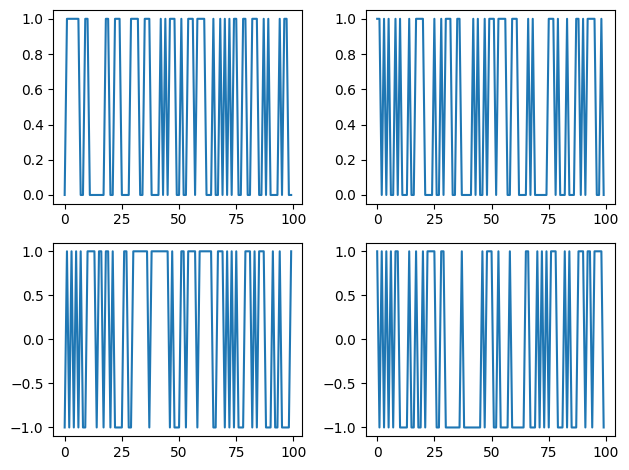

[0.53529474 0.46470526]
[0.49494967 0.50505033]


In [11]:
T = 100
history = []
for t in range(T):
    a0, p0 = stochastic_ficticious_play(0, t, history, R0, R1, 1)
    a1, p1 = stochastic_ficticious_play(1, t, history, R0, R1, 1)
    r0, r1 = normal_form_game(a0, a1, R0, R1)
    history.append([a0, a1, r0, r1, p0, p1])

plot_history(history)
print(p0)
print(p1)